In [1]:
# ================= PORT NA KONWENCJE ARTYKULU (06.09.2026) =================
# PORT 20260831a.ipynb. Ten notebook nie liczy statystyki sam - czyta zapisane
# krzywe. Port polega WYLACZNIE na tym, ze czyta teraz pliki credo_* (nowa
# konwencja, 20260906a.ipynb) zamiast finetune_*, a swoje wyjscia zapisuje
# z przedrostkiem credo_, zeby nie nadpisac wynikow z sierpnia i wrzesnia.
# Kod analityczny, reguly odczytu i wykresy sa NIETKNIETE.
# Powod zmiany konwencji: dziennik 20260905.txt pkt 13a-13g.
# ==========================================================================

# 31.08.2026 - Watek 1 (PRIORYTET) z planu 20260831/20260831_plan.md:
# sekcja 4 artykulu na 20 stacjach, znak-slepo (find_peaks na -log10 PPDF
# bez filtra fazy) - test, czy siec odtwarza caly ~10-letni ciag minimow
# z Fig.4, nie tylko jedna ere 2008-09 (naglowek z 26.08, patrz
# project_station_data_quality.md i project_cycle_to_cycle_map.md w
# pamieci Claude'a).
#
# WEJSCIE: wylacznie juz policzone pliki
# results/credo_{stacja}_P3350_d5_dt15_fullhistory.csv (26.08,
# 20260826d.ipynb) - zero nowych skanow, zero zapytan do NMDB. Katalog
# EQ czytany ponizej wylacznie do diagnostyki jednorodnosci (komorka 6),
# nie do liczenia statystyki. Funkcja cosmoseismic_stat NIE jest tu
# uzywana - nic nie przeliczamy, tylko reanalizujemy gotowe wyniki.
#
# STACJE: 20 uzywanych w analizie (bez mcrl, nanm - wykluczone 26.08,
# patrz project_station_data_quality.md).
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

RESULTS_DIR = "../results"
DATA_DIR = "../data"

STATIONS = [
    "aatb", "apty", "athn", "fsmt", "hrms", "invk", "jung", "jung1",
    "lmks", "mosc", "mxco", "nain", "newk", "oulu", "psnm", "pwnk",
    "sopb", "sopo", "tera", "thul",
]

P_DAYS = 3350
D_DAYS = 5
STEP_DAYS = 0.25  # krok 6h uzyty w skanie 26.08 (20260826d.ipynb)

finetune = {}
for st in STATIONS:
    path = f"{RESULTS_DIR}/credo_{st}_P{P_DAYS}_d{D_DAYS}_dt15_fullhistory.csv"
    df = pd.read_csv(path, parse_dates=["t0"]).sort_values("t0").reset_index(drop=True)
    finetune[st] = df

for st, df in finetune.items():
    print(f"{st}: {len(df)} punktow, {df['t0'].min().date()} .. {df['t0'].max().date()}")
print(f"Lacznie {len(finetune)} stacji.")

aatb: 62636 punktow, 1973-01-01 .. 2015-11-15
apty: 22464 punktow, 2000-07-01 .. 2015-11-15
athn: 21933 punktow, 2000-11-10 .. 2015-11-15
fsmt: 22084 punktow, 2000-10-04 .. 2015-11-15
hrms: 69752 punktow, 1965-01-01 .. 2012-09-29
invk: 23192 punktow, 2000-01-01 .. 2015-11-15
jung: 74322 punktow, 1965-01-01 .. 2015-11-15
jung1: 43644 punktow, 1986-01-01 .. 2015-11-15
lmks: 47388 punktow, 1981-12-01 .. 2014-05-08
mosc: 74322 punktow, 1965-01-01 .. 2015-11-15
mxco: 37800 punktow, 1990-01-01 .. 2015-11-15
nain: 21933 punktow, 2000-11-10 .. 2015-11-15
newk: 74322 punktow, 1965-01-01 .. 2015-11-15
oulu: 67020 punktow, 1970-01-01 .. 2015-11-15
psnm: 11596 punktow, 2007-12-09 .. 2015-11-15
pwnk: 22164 punktow, 2000-09-14 .. 2015-11-15
sopb: 26116 punktow, 1997-12-31 .. 2015-11-15
sopo: 74322 punktow, 1965-01-01 .. 2015-11-15
tera: 69460 punktow, 1968-05-01 .. 2015-11-15
thul: 74322 punktow, 1965-01-01 .. 2015-11-15
Lacznie 20 stacji.


In [2]:
# Detekcja minimow per stacja, ZNAK-SLEPO: szczyty na -log10(PPDF), bez
# zadnego filtra na faze (sigma>0/<0) - w odroznieniu od 26.08
# (20260826e.ipynb), gdzie liczono "najlepszy punkt" tylko w fazie
# ordering. Znak (ordering/disordering) odczytywany PO fakcie z kolumny
# sigma (dodatnie = nadmiar N+ = ordering, ujemne = disordering -
# definicja w cosmoseismic_stat, 20260826d.ipynb komorka 0).
#
# distance: kryterium artykulu "all four minima occur in non-overlapping
# periods of P_days" -> odstep w probkach = P_days / krok(dni).
# height: PROG SPARAMETRYZOWANY (plan, krok 1) - 5.0 z podgladu Opusa
# jest arbitralny, wiec sprawdzamy DWIE wartosci i raportujemy obie.
HEIGHT_THRESHOLDS = [5.0, 6.0]
DISTANCE_SAMPLES = int(round(P_DAYS / STEP_DAYS))


def find_minima(df, height):
    y = -np.log10(df["PPDF"].to_numpy())
    peaks, _ = find_peaks(y, height=height, distance=DISTANCE_SAMPLES)
    out = df.iloc[peaks].copy()
    out["neglog10_PPDF"] = y[peaks]
    out["sign"] = np.where(out["sigma"] > 0, "ordering", "disordering")
    return out


rows = []
for st, df in finetune.items():
    for h in HEIGHT_THRESHOLDS:
        minima = find_minima(df, h).assign(station=st, height_threshold=h)
        rows.append(minima[["station", "height_threshold", "t0", "PPDF", "neglog10_PPDF",
                             "sigma", "sign", "N_valid", "Np", "Nm"]])

all_minima = pd.concat(rows, ignore_index=True)
print(f"Lacznie znalezionych minimow: {len(all_minima)}")
print(all_minima.groupby("height_threshold").size())
all_minima.sort_values(["height_threshold", "station", "t0"]).head(20)

Lacznie znalezionych minimow: 104
height_threshold
5.0    55
6.0    49
dtype: int64


,station,height_threshold,t0,PPDF,neglog10_PPDF,sigma,sign,N_valid,Np,Nm
0,aatb,5.0,1979-02-25 06:00:00,8.198316e-09,8.086275,-5.545198,disordering,670,264,406
1,aatb,5.0,1989-02-13 18:00:00,1.405132e-08,7.852283,-5.461369,disordering,589,229,358
2,aatb,5.0,1999-04-03 18:00:00,2.653751e-14,13.576140,-7.502027,disordering,644,228,416
3,aatb,5.0,2008-07-03 18:00:00,2.035679e-08,7.691291,5.299936,ordering,663,400,261
8,apty,5.0,2008-11-21 00:00:00,4.303109e-13,12.366218,7.035436,ordering,670,426,244
10,athn,5.0,2008-08-07 18:00:00,4.856588e-11,10.313669,6.332503,ordering,661,412,247
12,fsmt,5.0,2009-04-15 00:00:00,1.080171e-11,10.966508,6.563647,ordering,670,420,250
14,hrms,5.0,1968-05-24 06:00:00,1.396069e-13,12.855093,-7.271762,disordering,670,242,428
15,hrms,5.0,1978-09-18 06:00:00,1.912398e-08,7.718422,-5.388927,disordering,670,266,404
16,hrms,5.0,1988-07-27 18:00:00,3.784751e-12,11.421963,-6.799394,disordering,670,248,422


In [3]:
# Przypisanie er kalendarzowych metoda odstepow (gap-based clustering),
# NIE po numerze cyklu slonecznego (lekcja z 24.08 -
# project_cycle_to_cycle_map.md: sztywne granice cyklu myla realna
# strukture). Zasada: sortujemy WSZYSTKIE daty minimow (prog=5.0,
# podstawowy) ze wszystkich stacji, i tam gdzie odstep miedzy kolejnymi
# datami > GAP_YEARS lat - nowa era. Odzwierciedla to rytm ~10-letni z
# artykulu (odstepy miedzy erami rzedu 10 lat, rozrzut w obrebie ery
# rzedu miesiecy/pojedynczych lat).
GAP_YEARS = 4.0

primary = all_minima[all_minima["height_threshold"] == 5.0].copy()
primary = primary.sort_values("t0").reset_index(drop=True)
gaps_years = primary["t0"].diff().dt.days / 365.25
primary["era_id"] = (gaps_years > GAP_YEARS).cumsum()

era_table = primary.groupby("era_id")["t0"].median().rename("era_center").to_frame()
era_table["era_min"] = primary.groupby("era_id")["t0"].min()
era_table["era_max"] = primary.groupby("era_id")["t0"].max()
era_table["n_stacji"] = primary.groupby("era_id")["station"].nunique()
era_table["label"] = era_table["era_center"].dt.year.astype(str)
print(era_table)

primary = primary.merge(era_table[["label"]], left_on="era_id", right_index=True)
primary = primary.rename(columns={"label": "era"})

                era_center             era_min             era_max  n_stacji  \
era_id                                                                         
0      1968-05-24 06:00:00 1968-01-10 12:00:00 1968-07-12 12:00:00         7   
1      1972-08-23 18:00:00 1972-08-23 18:00:00 1972-08-23 18:00:00         1   
2      1978-06-29 12:00:00 1977-11-22 12:00:00 1979-02-25 06:00:00         6   
3      1988-12-10 21:00:00 1988-05-29 12:00:00 1989-06-03 00:00:00        10   
4      1999-02-18 00:00:00 1998-01-04 18:00:00 2000-09-23 06:00:00        13   
5      2008-11-16 09:00:00 2008-06-14 06:00:00 2009-04-15 00:00:00        16   
6      2014-04-05 12:00:00 2014-03-04 00:00:00 2014-05-08 00:00:00         2   

       label  
era_id        
0       1968  
1       1972  
2       1978  
3       1988  
4       1999  
5       2008  
6       2014  


In [4]:
# Przypisanie tych samych er do progu 6.0 (test odpornosci na wybor
# progu, plan krok 1) - metoda: najblizsze centrum ery w oknie +-2 lata
# (plan, krok 3: "minima w oknie +-2 lata wokol mediany daty danej
# ery"). Poza oknem = brak przypisania (era=NaN) - to jest informacja,
# nie blad.
ERA_WINDOW_YEARS = 2.0

secondary = all_minima[all_minima["height_threshold"] == 6.0].copy().sort_values("t0")
centers_sorted = era_table[["era_center", "label"]].sort_values("era_center")

merged = pd.merge_asof(
    secondary, centers_sorted, left_on="t0", right_on="era_center",
    direction="nearest", tolerance=pd.Timedelta(days=365.25 * ERA_WINDOW_YEARS),
)
secondary = merged.rename(columns={"label": "era"}).drop(columns=["era_center"])

print("Prog 5.0 - minimow z przypisana era:", primary["era"].notna().sum(), "/", len(primary))
print("Prog 6.0 - minimow z przypisana era:", secondary["era"].notna().sum(), "/", len(secondary))
print()
print("Liczba stacji na era (prog 5.0):")
print(primary.groupby("era")["station"].nunique())
print()
print("Liczba stacji na era (prog 6.0):")
print(secondary.groupby("era")["station"].nunique())

Prog 5.0 - minimow z przypisana era: 55 / 55
Prog 6.0 - minimow z przypisana era: 49 / 49

Liczba stacji na era (prog 5.0):
era
1968     7
1972     1
1978     6
1988    10
1999    13
2008    16
2014     2
Name: station, dtype: int64

Liczba stacji na era (prog 6.0):
era
1968     6
1978     5
1988     9
1999    13
2008    15
2014     1
Name: station, dtype: int64


In [5]:
# Dostepnosc danych: dla kazdej pary stacja x era sprawdzamy, czy WLASNY
# zakres skanu danej stacji (t0.min()..t0.max() z finetune, nie okno
# erowe) w ogole pokrywa okno erowe (era_center +- ERA_WINDOW_YEARS).
# Bez tej korekty kazda liczba "X z 20 stacji" w danej erze jest bez
# sensu - 8 z 20 stacji zaczyna sie dopiero 1997-2007 (plan, sekcja 1.2
# pkt 4 i sekcja 5).
availability = []
for st, df in finetune.items():
    t0_min, t0_max = df["t0"].min(), df["t0"].max()
    for era_id, row in era_table.iterrows():
        window_start = row["era_center"] - pd.Timedelta(days=365.25 * ERA_WINDOW_YEARS)
        window_end = row["era_center"] + pd.Timedelta(days=365.25 * ERA_WINDOW_YEARS)
        has_data = (t0_min <= window_end) and (t0_max >= window_start)
        availability.append(dict(station=st, era=row["label"], has_data_in_era=has_data,
                                  station_t0_min=t0_min, station_t0_max=t0_max))

availability = pd.DataFrame(availability)
print(availability.groupby("era")["has_data_in_era"].sum())

era
1968     8
1972     9
1978     9
1988    12
1999    19
2008    20
2014    20
Name: has_data_in_era, dtype: int64


In [6]:
# Finalna tabela dlugo-formatowa stacja x era: czy stacja miala dane w
# erze, czy trafila w minimum (prog 5.0 i osobno prog 6.0), wartosci
# -log10 PPDF i znak. Zapis do results/section4_network_minima.csv - to
# jest wyjscie watku 1 (plan, sekcja 3).
found5 = primary[["station", "era", "t0", "neglog10_PPDF", "sigma", "sign", "N_valid"]].rename(
    columns={"t0": "t0_h5", "neglog10_PPDF": "neglog10_PPDF_h5", "sigma": "sigma_h5",
             "sign": "sign_h5", "N_valid": "N_valid_h5"})
found6 = secondary[["station", "era", "t0", "neglog10_PPDF", "sign"]].rename(
    columns={"t0": "t0_h6", "neglog10_PPDF": "neglog10_PPDF_h6", "sign": "sign_h6"})

network_table = availability.merge(found5, on=["station", "era"], how="left")
network_table = network_table.merge(found6, on=["station", "era"], how="left")
network_table["matched_h5"] = network_table["t0_h5"].notna()
network_table["matched_h6"] = network_table["t0_h6"].notna()
network_table = network_table.sort_values(["era", "station"]).reset_index(drop=True)

network_table.to_csv(f"{RESULTS_DIR}/credo_section4_network_minima.csv", index=False)
print(f"Zapisano {RESULTS_DIR}/credo_section4_network_minima.csv, {len(network_table)} wierszy")

summary = network_table.groupby("era").agg(
    n_stacji_z_danymi=("has_data_in_era", "sum"),
    n_trafien_h5=("matched_h5", "sum"),
    n_trafien_h6=("matched_h6", "sum"),
)
summary["frakcja_h5"] = summary["n_trafien_h5"] / summary["n_stacji_z_danymi"]
print(summary)

Zapisano ../results/credo_section4_network_minima.csv, 140 wierszy
      n_stacji_z_danymi  n_trafien_h5  n_trafien_h6  frakcja_h5
era                                                            
1968                  8             7             6    0.875000
1972                  9             1             0    0.111111
1978                  9             6             5    0.666667
1988                 12            10             9    0.833333
1999                 19            13            13    0.684211
2008                 20            16            15    0.800000
2014                 20             2             1    0.100000


In [7]:
# Diagnostyka jednorodnosci katalogu EQ (punkt Opusa z 24.08, plan krok
# 5): czy stare ery maja systematycznie mniej danych sejsmicznych niz
# era 2008-09? Liczba zdarzen M>=4.0 na rok z rozszerzonego katalogu
# uzywanego w skanie 26.08 (ten sam plik co w cosmoseismic_stat,
# 20260826d.ipynb komorka 0).
USGS_EXTENDED_PATH = f"{DATA_DIR}/usgs_data/usgs_m4_1965_2025.csv"

eq = pd.read_csv(USGS_EXTENDED_PATH, usecols=["time", "mag"])
eq["time"] = pd.to_datetime(eq["time"], utc=True).dt.tz_localize(None)
eq = eq[eq["mag"] >= 4.0]

eq_per_year = eq.set_index("time").resample("YE").size()
eq_per_year.index = eq_per_year.index.year
print(eq_per_year)

time
1965      689
1966      623
1967      622
1968      764
1969      710
        ...  
2021    17297
2022    15749
2023    16231
2024    14175
2025     1413
Length: 61, dtype: int64


Zapisano ../results/credo_eq_catalog_homogeneity.png


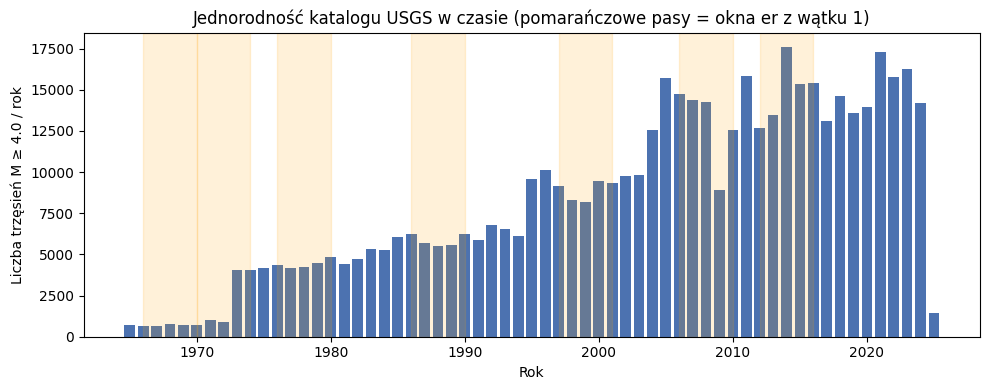

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(eq_per_year.index, eq_per_year.values, color="#4C72B0")
for _, row in era_table.iterrows():
    ax.axvspan(row["era_center"].year - ERA_WINDOW_YEARS, row["era_center"].year + ERA_WINDOW_YEARS,
               color="orange", alpha=0.15)
ax.set_xlabel("Rok")
ax.set_ylabel("Liczba trzęsień M ≥ 4.0 / rok")
ax.set_title("Jednorodność katalogu USGS w czasie (pomarańczowe pasy = okna er z wątku 1)")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/credo_eq_catalog_homogeneity.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/credo_eq_catalog_homogeneity.png")

Zapisano ../results/credo_n_valid_vs_t0.png


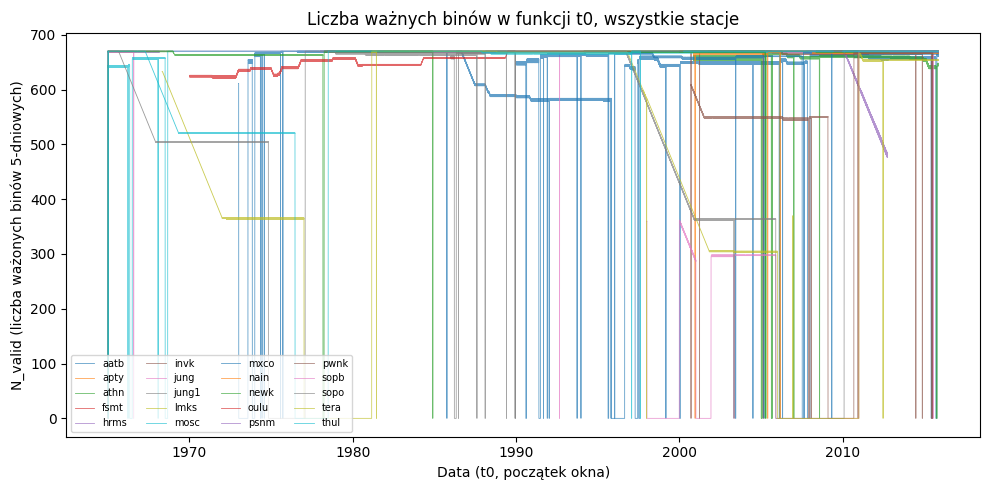

In [9]:
# Drugi aspekt jednorodnosci (plan krok 5): N_valid (liczba wazonych
# binow w cosmoseismic_stat, kolumna dostepna od razu w kazdym pliku
# finetune) w funkcji t0, per stacja - spadek N_valid w starszych latach
# oznaczalby mniej wiarygodne minima z tamtego okresu.
fig, ax = plt.subplots(figsize=(10, 5))
for st, df in finetune.items():
    ax.plot(df["t0"], df["N_valid"], lw=0.6, alpha=0.7, label=st)
ax.set_xlabel("Data (t0, początek okna)")
ax.set_ylabel("N_valid (liczba ważonych binów 5-dniowych)")
ax.set_title("Liczba ważnych binów w funkcji t0, wszystkie stacje")
ax.legend(ncol=4, fontsize=7, loc="lower left")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/credo_n_valid_vs_t0.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/credo_n_valid_vs_t0.png")

Zapisano ../results/credo_section4_network_timeline.png


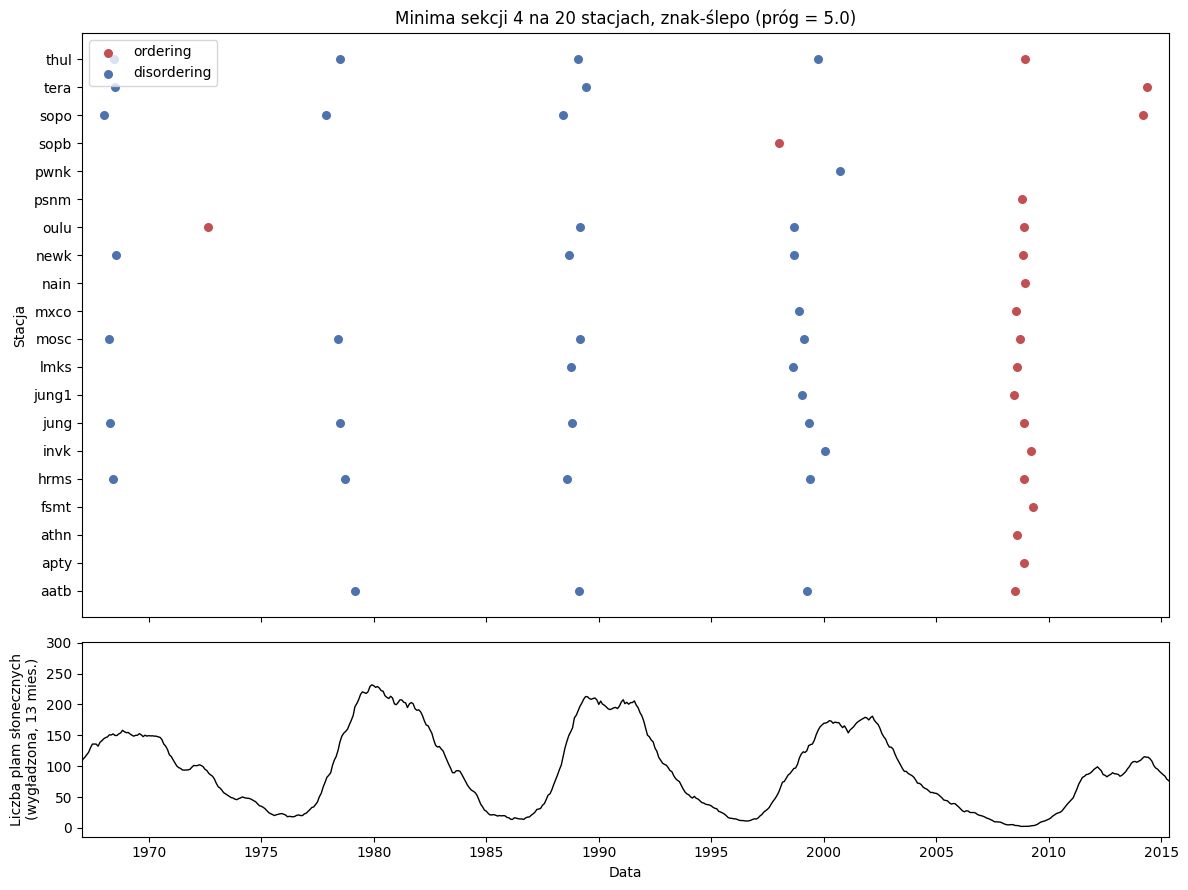

In [10]:
# Wykres glowny watku 1 (plan krok 6): (a) os czasu, jeden wiersz na
# stacje, kropki = minima (prog 5.0), kolor = znak (ordering/
# disordering); (b) pod spodem, ta sama os X, liczba plam slonecznych
# wygladzona oknem 13-miesiecznym (konwencja Fig.4 artykulu - plan
# sekcja 5).
sn = pd.read_csv(f"{DATA_DIR}/SN_m_tot_V2.0.csv", sep=";")
sn["date"] = pd.to_datetime(dict(year=sn["rok"], month=sn["miesiac"], day=1))
sn = sn.sort_values("date")
sn["sunspot_smooth"] = sn["sunspot"].rolling(13, center=True, min_periods=1).mean()

station_order = sorted(finetune.keys())
y_pos = {st: i for i, st in enumerate(station_order)}
color_map = {"ordering": "#C44E52", "disordering": "#4C72B0"}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})

for sign, color in color_map.items():
    sub = primary[primary["sign"] == sign]
    ax1.scatter(sub["t0"], sub["station"].map(y_pos), c=color, s=30, label=sign, zorder=3)

ax1.set_yticks(list(y_pos.values()))
ax1.set_yticklabels(list(y_pos.keys()))
ax1.set_ylabel("Stacja")
ax1.legend(loc="upper left")
ax1.set_title("Minima sekcji 4 na 20 stacjach, znak-ślepo (próg = 5.0)")

ax2.plot(sn["date"], sn["sunspot_smooth"], color="black", lw=1)
ax2.set_ylabel("Liczba plam słonecznych\n(wygładzona, 13 mies.)")
ax2.set_xlabel("Data")
ax2.set_xlim(primary["t0"].min() - pd.Timedelta(days=365), primary["t0"].max() + pd.Timedelta(days=365))

fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/credo_section4_network_timeline.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/credo_section4_network_timeline.png")